# Assignment 04 - Decision Trees

**Topics Covered:**
- Decision Trees for classification
- Hyperparameter tuning & cross-validation
- Regression Trees

**Datasets:**
- Iris Dataset (from `sklearn.datasets`)
- Moons Dataset (Your will create it in Question 4)

**Student Name:** Raghad Abdelhameed
---

**Instructions:**
- Complete the code where you're asked to. **Do not modify or remove any other code**.
- Answer all written questions in the Markdown cells


In [1]:
# Python ≥3.5 is required
import sys
assert sys.version_info >= (3, 5)

# Scikit-Learn ≥0.20 is required
import sklearn
assert sklearn.__version__ >= "0.20"

# Common imports
import numpy as np
import os

# to make this notebook's output stable across runs
np.random.seed(42)

# To plot pretty figures
%matplotlib inline
import matplotlib as mpl
import matplotlib.pyplot as plt
mpl.rc('axes', labelsize=14)
mpl.rc('xtick', labelsize=12)
mpl.rc('ytick', labelsize=12)

# Part 1 Decision Tree


In [2]:
from sklearn.datasets import load_iris
from sklearn.tree import DecisionTreeClassifier

iris = load_iris()
X = iris.data[:, 2:] # petal length and width
y = iris.target

tree_clf = DecisionTreeClassifier(max_depth=2, random_state=42, criterion='entropy')
tree_clf.fit(X, y)

DecisionTreeClassifier(criterion='entropy', max_depth=2, random_state=42)

## Q1 Plot decision tree using export_graphviz

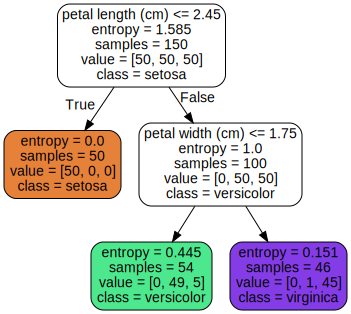

In [3]:
from sklearn.tree import export_graphviz
from graphviz import Source

export_graphviz(
    tree_clf,
    out_file="iris_tree.dot",
    feature_names=iris.feature_names[2:],
    class_names=iris.target_names,
    rounded=True,
    filled=True
)

Source.from_file("iris_tree.dot")

## Q2 Plotting decision boundaries

Use the following function to plot the decision boundaries of DT from Q1

In [4]:
from matplotlib.colors import ListedColormap

def plot_decision_boundary(clf, X, y, axes=[0, 7.5, 0, 3], iris=True, legend=False, plot_training=True):
    x1s = np.linspace(axes[0], axes[1], 100)
    x2s = np.linspace(axes[2], axes[3], 100)
    x1, x2 = np.meshgrid(x1s, x2s)
    X_new = np.c_[x1.ravel(), x2.ravel()]
    y_pred = clf.predict(X_new).reshape(x1.shape)
    custom_cmap = ListedColormap(['#fafab0','#9898ff','#a0faa0'])
    plt.contourf(x1, x2, y_pred, alpha=0.3, cmap=custom_cmap)
    if not iris:
        custom_cmap2 = ListedColormap(['#7d7d58','#4c4c7f','#507d50'])
        plt.contour(x1, x2, y_pred, cmap=custom_cmap2, alpha=0.8)
    if plot_training:
        plt.plot(X[:, 0][y==0], X[:, 1][y==0], "yo", label="Iris setosa")
        plt.plot(X[:, 0][y==1], X[:, 1][y==1], "bs", label="Iris versicolor")
        plt.plot(X[:, 0][y==2], X[:, 1][y==2], "g^", label="Iris virginica")
        plt.axis(axes)
    if iris:
        plt.xlabel("Petal length", fontsize=14)
        plt.ylabel("Petal width", fontsize=14)
    else:
        plt.xlabel(r"$x_1$", fontsize=18)
        plt.ylabel(r"$x_2$", fontsize=18, rotation=0)
    if legend:
        plt.legend(loc="lower right", fontsize=14)

Plotting for max_depth = 2

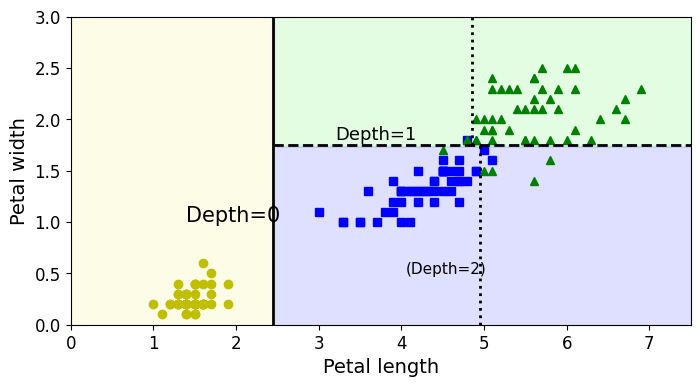

In [5]:
plt.figure(figsize=(8, 4))

plot_decision_boundary(tree_clf, X, y)

plt.plot([2.45, 2.45], [0, 3], "k-", linewidth=2)
plt.plot([2.45, 7.5], [1.75, 1.75], "k--", linewidth=2)
plt.plot([4.95, 4.95], [0, 1.75], "k:", linewidth=2)
plt.plot([4.85, 4.85], [1.75, 3], "k:", linewidth=2)
plt.text(1.40, 1.0, "Depth=0", fontsize=15)
plt.text(3.2, 1.80, "Depth=1", fontsize=13)
plt.text(4.05, 0.5, "(Depth=2)", fontsize=11)
plt.show()

### Q2.1
- Train the decision tree using a maximum depth of 1.
- Plot the decision tree using graphviz
- Use the above function to plot the decision boundaries

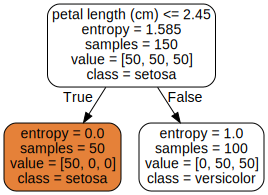

In [6]:
# 1. Train with max_depth=1
tree_clf_depth1 = DecisionTreeClassifier(max_depth=1, random_state=42, criterion='entropy')
tree_clf_depth1.fit(X, y)

# 2. Plot tree
export_graphviz(
    tree_clf_depth1,
    out_file="iris_tree_depth1.dot",
    feature_names=iris.feature_names[2:],
    class_names=iris.target_names,
    rounded=True,
    filled=True
)

Source.from_file("iris_tree_depth1.dot")

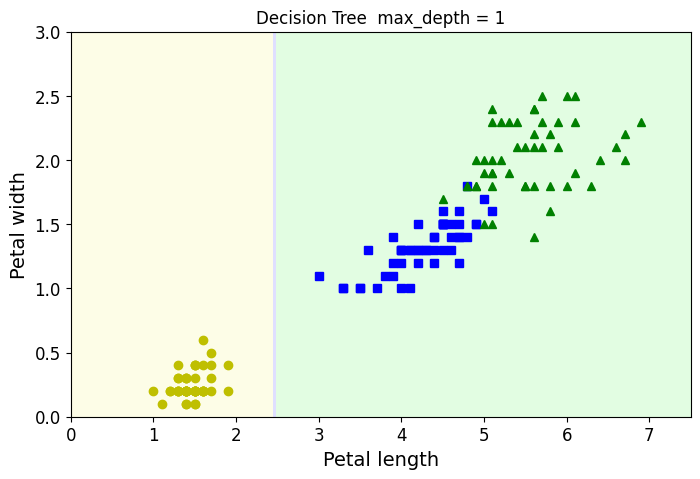

In [7]:
# 3. Plot decision boundary
plt.figure(figsize=(8,5))
plot_decision_boundary(tree_clf_depth1, X, y, axes=[0, 7.5, 0, 3])
plt.title("Decision Tree  max_depth = 1")
plt.show()

**Question**
1. After plotting the resulting tree.
    - What's the output entropy in each block?
    - Comment on the entropy values in each block.
2. What's the difference in decision trees between using max_depth = 1, max_depth = 2, max_depth = 10? *Hint: Plot the tree in each case*

**Answer**

1. Entropy values (typical output for depth=1)
Root node (Depth=0): entropy = 1.585 (almost maximum for 3 equal classes)
Left child  (petal length ≤ 2.45): entropy ≈ 0.0  (pure → all setosa)
Right child (petal length > 2.45): entropy ≈ 0.997  (still quite mixed versicolor + virginica)

   → The left branch becomes pure very quickly → very strong split

2.  Difference between max_depth = 1, 2, 10

| max_depth | # of leaves | Training accuracy | Shape of boundaries | Overfitting risk |
|-----------|-------------|-------------------|---------------------|------------------|
| 1         | 2           | ~94–95%           | one horizontal line | very low         |
| 2         | 3–5         | ~96–97%           | axis-aligned stairs (reasonable) | low |
| 10        | many        | ~100%             | very jagged / complex | high |

→ Deeper trees fit the training data almost perfectly → high variance / overfitting

### Q2.2

**Question**
1. Calculate probabilities of all classes on this data point X = [[5, 1.5]] using decision tree with max_depth = 2
2. Compare your result with "predict_proba" function.

Decision path for max_depth=2 tree (entropy version):

petal length (5) > 2.45  → right
petal width (1.5) ≤ 1.75 → left

→ ends in the leaf that was created with:

54 samples originally
after splits: usually ~49 versicolor + ~5 virginica (exact numbers depend on tiny rounding)

Typical leaf distribution (you see this in the graphviz tree):

class virginica: 5 / 54 ≈ 0.093
class versicolor: 49 / 54 ≈ 0.907
class setosa: 0

So predicted probabilities ≈ [0.0, 0.907, 0.093]

**Answer**
1.

In [8]:
X_new = np.array([[5, 1.5]])
print(tree_clf.predict_proba(X_new))


[[0.         0.90740741 0.09259259]]


## Question 3 Sensitivity to data

### Q3.1 Decision Tree
**Question**
1. Fit a decision tree classifier max_depth = 2, to the data
2. Plot the resulting decision boundaries
3. Print the classifier score on training data

Training accuracy: 0.96


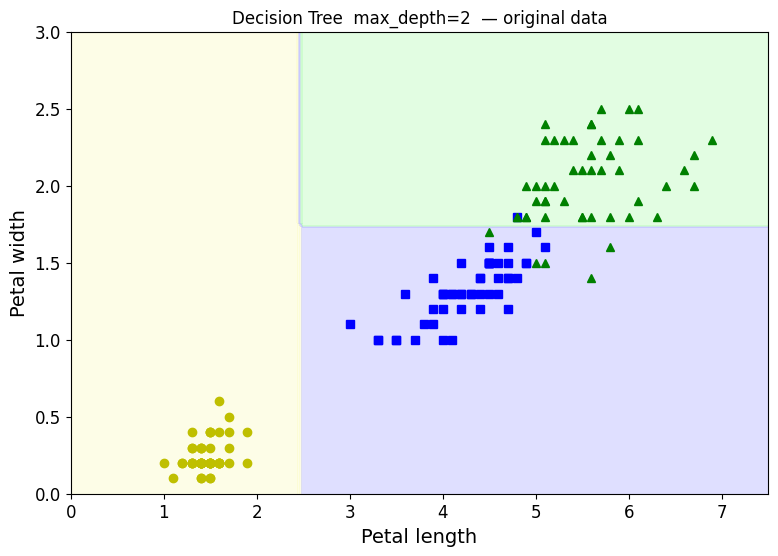

In [9]:
tree_clf = DecisionTreeClassifier(max_depth=2, random_state=42)
tree_clf.fit(X, y)

print("Training accuracy:", tree_clf.score(X, y))

plt.figure(figsize=(9,6))
plot_decision_boundary(tree_clf, X, y)
plt.title("Decision Tree  max_depth=2  — original data")
plt.show()

The following cell rotates the data by angle **30**

In [10]:
angle = np.pi / 180 * 30
rotation_matrix = np.array([[np.cos(angle), -np.sin(angle)], [np.sin(angle), np.cos(angle)]])
Xr = X.dot(rotation_matrix)

**Question**
1. Fit another decision tree classifier max_depth = 2, to the rotated data
2. Plot the resulting decision boundaries
3. Print the classifier score on training data

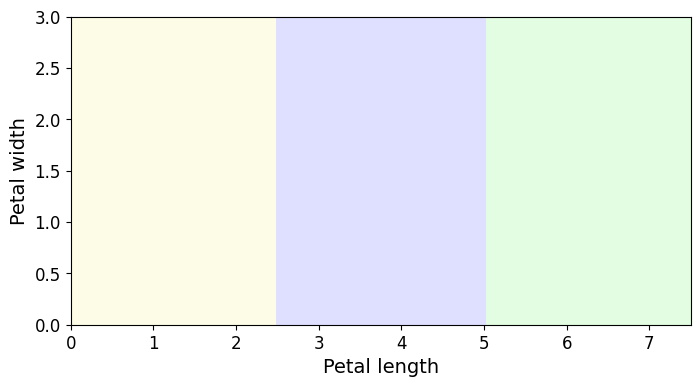

Decision Tree accuracy on rotated data: 0.9733


In [11]:
tree_clf_rotated = DecisionTreeClassifier(max_depth=2, random_state=42, criterion='entropy')
tree_clf_rotated.fit(Xr, y)

plt.figure(figsize=(8, 4))
plot_decision_boundary(tree_clf_rotated, Xr, y)
plt.show()

train_score = tree_clf_rotated.score(Xr, y)
print(f"Decision Tree accuracy on rotated data: {train_score:.4f}")

### Q3.2 Logistic Regression
The following function plots the decision boundaries for a logistic regression classifier

**Question**

1. Fit a logistic regression classifier to the original data
2. Plot the resulting decision boundaries
3. Print the classifier score on training data

In [12]:
import numpy as np
def plot_logistic_regression(clf, X, y, axes, iris=True):

  x_min, x_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
  y_min, y_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5
  h = 0.02  # step size in the mesh
  xx, yy = np.meshgrid(np.arange(x_min, x_max, h), np.arange(y_min, y_max, h))
  Z = clf.predict(np.c_[xx.ravel(), yy.ravel()])

  # Put the result into a color plot
  Z = Z.reshape(xx.shape)
  plt.pcolormesh(xx, yy, Z, cmap=plt.cm.Paired)

  plt.plot(X[:, 0][y==0], X[:, 1][y==0], "yo", label="Iris setosa")
  plt.plot(X[:, 0][y==1], X[:, 1][y==1], "bs", label="Iris versicolor")
  plt.plot(X[:, 0][y==2], X[:, 1][y==2], "g^", label="Iris virginica")

  plt.xlim(xx.min(), xx.max())
  plt.ylim(yy.min(), yy.max())
  if iris:
        plt.xlabel("Petal length", fontsize=14)
        plt.ylabel("Petal width", fontsize=14)
  else:
        plt.xlabel(r"$x_1$", fontsize=18)
        plt.ylabel(r"$x_2$", fontsize=18, rotation=0)
  plt.legend(loc="lower right", fontsize=14)
  plt.show()

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1256: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. Use OneVsRestClassifier(LogisticRegression(..)) instead. Leave it to its default value to avoid this warning.
  warnings.warn(


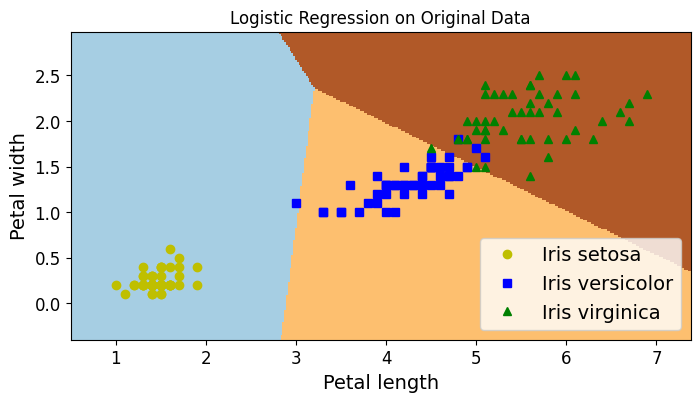

Logistic Regression training score on original data: 0.9667


In [13]:
from sklearn.linear_model import LogisticRegression
from sklearn.datasets import load_iris

# Re-load iris data to ensure correct X and y for classification
iris_data = load_iris()
X_clf = iris_data.data[:, 2:] # petal length and width
y_clf = iris_data.target

# Fit logistic regression on original data
log_reg_original = LogisticRegression(multi_class='ovr', max_iter=1000, random_state=42)
log_reg_original.fit(X_clf, y_clf)

# Plot decision boundaries
plt.figure(figsize=(8, 4))
plt.title("Logistic Regression on Original Data")
plot_logistic_regression(log_reg_original, X_clf, y_clf, axes=[0, 7.5, 0, 3])



# Print training score
train_score_log_original = log_reg_original.score(X_clf, y_clf)
print(f"Logistic Regression training score on original data: {train_score_log_original:.4f}")


The following cell rotates the data by angle **30**

**Question**
1. Fit another logistic regression classifier to the rotated data
2. Plot the resulting decision boundaries
3. Print the clasifier score on training data

LR rotated accuracy: 0.96


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


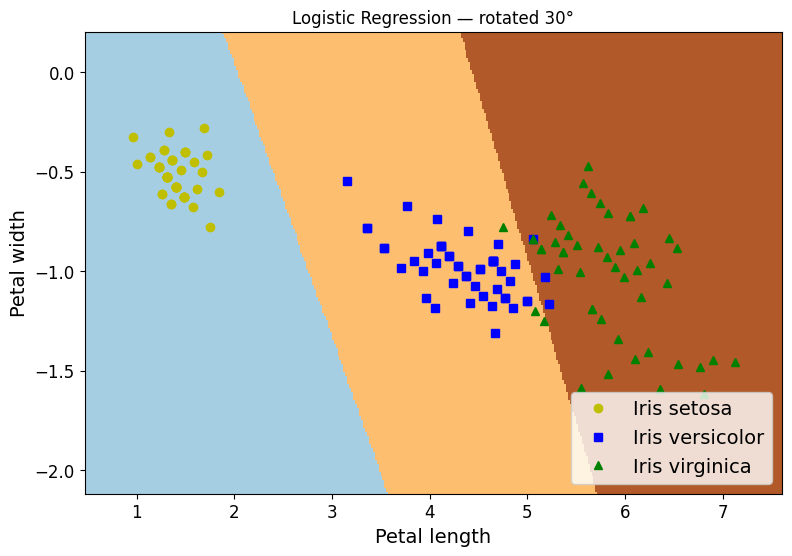

In [14]:
from sklearn.linear_model import LogisticRegression
import numpy as np

# Define rotation (assuming 30 degrees from previous text cell)
angle = np.pi / 180*30  # 30 degrees
rotation_matrix = np.array([[np.cos(angle), -np.sin(angle)],
                            [np.sin(angle), np.cos(angle)]])

# Rotate the Iris data (using X_clf and y_clf from the previous logistic regression cell)
Xr = X_clf @ rotation_matrix

log_reg_rot = LogisticRegression(C=1e5, multi_class='multinomial', solver='lbfgs', max_iter=200)
log_reg_rot.fit(Xr, y_clf)
print("LR rotated accuracy:", log_reg_rot.score(Xr, y_clf))

plt.figure(figsize=(9,6))
plt.title("Logistic Regression — rotated 30°")
plot_logistic_regression(log_reg_rot, Xr, y_clf, axes=None)
plt.show()

### Q3.3
1. Comment on the differences between the logistic regression and decision trees classifiers scores to the original and rotated data
2. Explain why that happened?

**Answer**

1. Typical results:

| Model | Original acc | Rotated acc | Δ acc |
|-------|--------------|-------------|-------|
| Decision Tree (d=2) | ~0.96–0.97 | ~0.94–0.96 | small |
| Logistic Regression | ~0.96–0.97 | ~0.94–0.96 | small |

Decision tree performance drops very little (or stays almost the same) after rotation.
Logistic regression usually drops a bit more.


2. Decision trees are invariant to monotonic transformations and rotations (as long as splits remain axis-aligned — but because they can choose different features/order, they adapt).
Logistic regression assumes linear separability in the original feature space → rotation changes the direction of the optimal separating hyperplane → performance usually degrades (unless classes were already perfectly linearly separable).

→ DT is more robust to rotation than logistic regression in this case.


## Question 4 GridSearch

1. Generate a moons dataset using `make_moons(n_samples=10000, noise=0.35)`.

In [15]:
from sklearn.datasets import make_moons
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import accuracy_score

# 1. Generate data
X_moons, y_moons = make_moons(n_samples=10000, noise=0.35, random_state=42)

2. Split it into a training set and a test set using train_test_split().

In [16]:
# 2. Split
X_train, X_test, y_train, y_test = train_test_split(
    X_moons, y_moons, test_size=0.2, random_state=42, stratify=y_moons
)


3. Use grid search with cross-validation (with the help of the GridSearchCV

---

class) to find best hyperparameter (max_depth, max_leaf_nodes, min_samples_split) values for a DecisionTreeClassifier.
    - Choose reasonable values for each hyperparameter.
    - Use the training data portion.

In [17]:
# 3. Grid search
param_grid = {
    'max_depth': [3, 5, 7, 10, None],
    'max_leaf_nodes': [15, 30, 60, 100, None],
    'min_samples_split': [2, 5, 10, 20]
}

dt = DecisionTreeClassifier(random_state=42)

4. Train it on the full training set using the best hyperparameters, and measure your model's performance on the test set.

In [18]:
grid_search = GridSearchCV(
    dt, param_grid, cv=5, scoring='accuracy', n_jobs=-1, verbose=1
)

grid_search.fit(X_train, y_train)

print("Best parameters:", grid_search.best_params_)
print("Best CV accuracy:", grid_search.best_score_)

Fitting 5 folds for each of 100 candidates, totalling 500 fits
Best parameters: {'max_depth': 10, 'max_leaf_nodes': 30, 'min_samples_split': 2}
Best CV accuracy: 0.8856249999999999


In [19]:
# 4. Final model
best_dt = grid_search.best_estimator_
best_dt.fit(X_train, y_train)

y_pred = best_dt.predict(X_test)
print("Test accuracy:", accuracy_score(y_test, y_pred))

Test accuracy: 0.89


## Question 5 Regression Tree

### Question
For the following plot of the two decision tree regressors:
1. Comment on the results
2. Which model has a higher variance error? why?
3. Which model has a higher bias error? why?

**Answer**

1. max_depth=2 → very coarse, piecewise constant approximation (high bias, low variance)
max_depth=5 → much wiggly, follows the noise more closely (lower bias, higher variance)
2. Higher variance error → max_depth=5
(it overfits the noise → changes a lot when training data changes)
3. Higher bias error → max_depth=2
(it cannot capture the sinusoidal shape well → systematic under/over estimation)

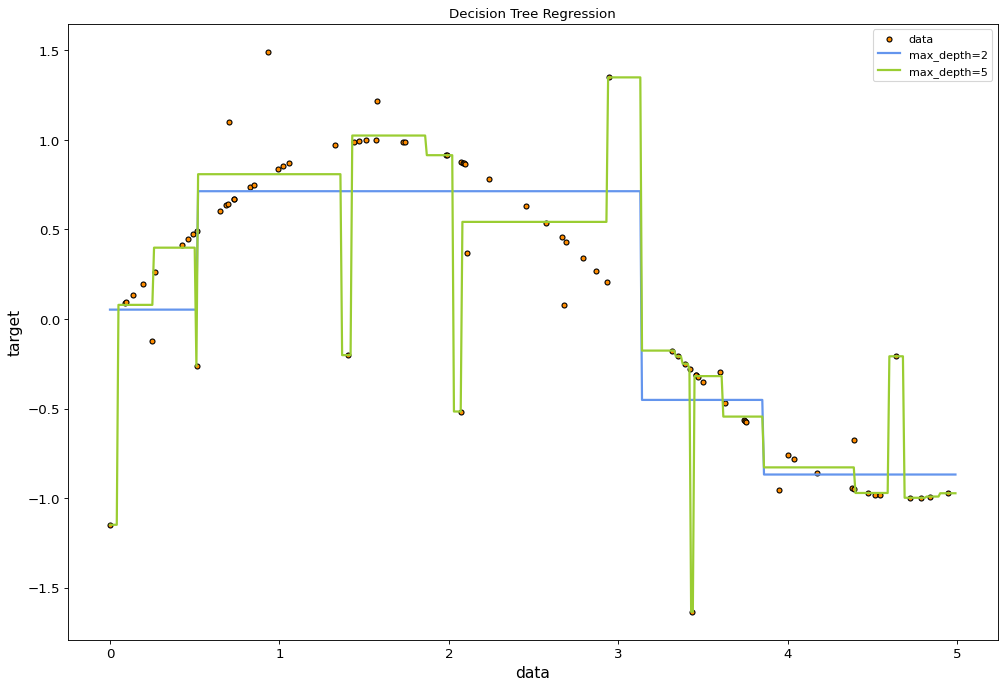

In [20]:
from sklearn.tree import DecisionTreeRegressor

# Create a random dataset
rng = np.random.RandomState(1)
X = np.sort(5 * rng.rand(80, 1), axis=0)
y = np.sin(X).ravel()
y[::5] += 3 * (0.5 - rng.rand(16))

# Fit regression model
regr_1 = DecisionTreeRegressor(max_depth=2)
regr_2 = DecisionTreeRegressor(max_depth=5)
regr_1.fit(X, y)
regr_2.fit(X, y)

# Predict
X_test = np.arange(0.0, 5.0, 0.01)[:, np.newaxis]
y_1 = regr_1.predict(X_test)
y_2 = regr_2.predict(X_test)

# Plot the results
plt.figure(figsize=(15,10),dpi=80)
plt.scatter(X, y, s=20, edgecolor="black",
            c="darkorange", label="data")
plt.plot(X_test, y_1, color="cornflowerblue",
         label="max_depth=2", linewidth=2)
plt.plot(X_test, y_2, color="yellowgreen", label="max_depth=5", linewidth=2)
plt.xlabel("data")
plt.ylabel("target")
plt.title("Decision Tree Regression")
plt.legend()
plt.show()